# 01. Data Understanding - nuImages

본 Notebook에서는 자율주행 환경의 2D Images Annotation을 수행하기 전에 
**nuImages v1.0-mini Dataset**의 구조와 특성을 탐색한다. 

Dataset의 **Sample (샘플), Category (카테고리), Attribute (속성), Object Annotation (객체 라벨링)** 등을 확인하여 
실제 **Pilot Annotation (시범 라벨링)**에 사용할 Class(분류)와 Annotation (라벨링) 기준을 설계하기 위한
기준을 설계하기 위한 기초 정보를 확보하는 것을 목적으로 한다. 

---

## DU-01. Environment & Library Setup

nuImages Dataset 탐색과 **Annotation Analysis (라벨링 분석)**, **Data Processing (데이터 가공)**, 
**Visualization (시각화)**에 필요한 Python Library를 불러온다. 

In [1]:
from nuimages import NuImages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("nuImages environment ready.")

nuImages environment ready.


## DU-02. Dataset Loading

**nuImages v1.0-mini Dataset**을 불러오기 전에 현재 Notebook의 **Working Directory**와 저장 경로를 확인한다. 

이를 통해 Python 환경에서 `data/raw` 폴더에 저장된 
niImages의 **Meatadata**와 **Image Data**에 정상적으로 접근할 수 있는지 확인한다. 

In [2]:
from pathlib import Path

# Check current working directory 
current_dir = Path.cwd()

print("Current working directory:")
print(current_dir)

Current working directory:
c:\Users\user\OneDrive\Documents\data-labeling-portfolio\03_autonomous_driving\notebooks


## DU-03. Load nuImages Dataset

확인한 **Working Directory(작업 디렉터리)**를 기준으로 
nuImages v1.0-mini의 **Dataset Root(데이터셋 루트 경로)**를 설정한다. 

`NuImages` Class(클래스)를 사용하여 Dataset(데이터셋)을 불러오고,
**Metadata(메타데이터)**와 Image(이미지) 파일이 정상적으로 연결되는지 확인한다. 

In [3]:
# Set nuImages dataset root
dataroot = Path("../data/raw").resolve()

print("Dataset root:")
print(dataroot)

print("\nDataset root exists:", dataroot.exists())

Dataset root:
C:\Users\user\OneDrive\Documents\data-labeling-portfolio\03_autonomous_driving\data\raw

Dataset root exists: True


In [4]:
# Load nuImages v1.0-mini
nuim = NuImages(
    dataroot=str(dataroot),
    version="v1.0-mini",
    verbose=True,
    lazy=True
)

print("\nnuImages v1.0-mini loaded successfully")

Loading nuImages tables for version v1.0-mini...
Done loading in 0.000 seconds (lazy=True).

nuImages v1.0-mini loaded successfully


## DU-04. Dataset Structure

nuImages Dataset(데이터셋)은 여러 **Metadata Table(메타데이터 테이블)**이 서로 연결된 구조로 구성되어 있다.

주요 Table의 Record(레코드) 수를 확인하여 Dataset의 전체 구조와 **Object Annotation(객체 라벨링)** 정보가 어떻게 구성되어 있는지 파악한다. 

주요 Table은 다음과 같다. 

- **Sample(샘플)**: Annotation의 기준이 되는 Keyframe(키프레임) 정보
- **Sample Data(샘플 데이터)**: Camera Image(카메라 이미지) 파일 및 Sensor(센서) 정보
- **Object Annotation(객체 라벨링)**: 객체별 2D Bounding Box(2D 경계 상자) 정보
- **Surface Annotation(영역 라벨링)**: 도로 등의 Semantic Mask(시맨틱 마스크) 정보\
- **Category(카테고리)**: 객체와 영역의 Class(클래스) 정의 
- **Attribute(속성)**: 객체의 상태 또는 행동 정보


In [5]:
# Check the number of records in major metadata tables 
tables = {
    "sample" : nuim.sample,
    "sample_data": nuim.sample_data,
    "object_ann": nuim.object_ann,
    "surface_ann": nuim.surface_ann,
    "category": nuim.category,
    "attribute":nuim.attribute
}

table_summary = pd.DataFrame({
    "table": tables.keys(),
    "records": [len(table) for table in tables.values()]
})

table_summary

Loaded 50 sample(s) in 0.007s,
Loaded 650 sample_data(s) in 0.004s,
Loaded 506 object_ann(s) in 0.005s,
Loaded 58 surface_ann(s) in 0.005s,
Loaded 25 category(s) in 0.002s,
Loaded 12 attribute(s) in 0.001s,


,table,records
0,sample,50
1,sample_data,650
2,object_ann,506
3,surface_ann,58
4,category,25
5,attribute,12


### Observation

- nuImages v1.0-mini는 총 **50개의 Sample(샘플)**로 구성되어 있다.
- 총 **506개의 Object Annotation(객체 라벨링)**이 포함되어 있어, 
  Sample당 평균 약 **10.1개의 객체**가 존재한다. 
- `sample_data`는 650개의 Record(레코드)를 포함하며, 하나의 Sample과 연결된 
  여러 Camera Image(카메라 이미지) 및 추가 데이터를 포함한다. 
- Dataset에는 **25개의 Category (카테고리)**와 **12개의 Attribute(속성)**가 
  정의되어 있으므로, Pilot Annotation(파일럿 라벨링)을 시작하기 전에 
  실제 Category와 Attribute의 구성 및 분포를 확인할 필요가 있다. 

## DU-05. Sample & Sample Data Analysis 

**Sample(샘플)**과 **Sample Data(샘플데이터)**의 구조를 확인하여
Annotation 대상이 되는 Keyframe(키프레임)과 실제 Camera Image(카메라 이미지)가 
어떻게 연결되어 있는지 파악한다. 

먼저 각 Metadata Table(메타데이터 테이블)의 주요 Field(필드)를 확인하고,
첫 번째 Record(레코드)를 통해 데이터 구조를 살펴본다. 

In [6]:
# Convert sample metadata to DataFrames
sample_df = pd.DataFrame(nuim.sample)
sample_data_df = pd.DataFrame(nuim.sample_data)

print("Sample shape:", sample_df.shape)
print("Sample Data shape:", sample_data_df.shape)

print("\nSample columns:")
print(sample_df.columns.tolist())

print("\nSample Data columns:")
print(sample_data_df.columns.tolist())

Sample shape: (50, 4)
Sample Data shape: (650, 12)

Sample columns:
['token', 'timestamp', 'log_token', 'key_camera_token']

Sample Data columns:
['token', 'sample_token', 'ego_pose_token', 'calibrated_sensor_token', 'filename', 'fileformat', 'width', 'height', 'timestamp', 'is_key_frame', 'prev', 'next']


In [7]:
sample_df.head()

,token,timestamp,log_token,key_camera_token
0,09acd654cb514bdeab8e3afedad74fca,1535352274870176,4ed5d1230fcb48d39db895f754e724f9,0128b121887b4d0d86b8b1a43ac001e9
1,09b7a70c10d94446b6932f894caf0a9e,1535342963787283,e3e0dc593b614a49a854e048576619c1,7d48524de48044048c88b94b25d4bdce
2,0b38985d779b4fcd94cf846006c93bed,1535514187537005,93f5da376907439482daa866a5363c20,4cabfd81faf64f4fa2711c449d6e15e8
3,0b8de86ffe9740ddb3d50b5a474bc7c3,1527712679297295,bf25bfdf8064437f847bc1c298e0a202,4afb21eec056459f87f22525eb9b59b2
4,0c04ea170e834a75a98218df768f33de,1530847097147633,38b69527a4c54f88a4a3e40513db4d0b,92a9f1547a9d46dca45cf7d0143cec96


In [8]:
sample_data_df.head()

,token,sample_token,ego_pose_token,calibrated_sensor_token,filename,fileformat,width,height,timestamp,is_key_frame,prev,next
0,003bf191da774ac3b7c47e44075d9cf9,d626e96768f44c2890c2a5693dd11ec4,2c731fd2f92b4956b15cbeed160417c1,d9480acc4135525dbcffb2a0db6d7c11,samples/CAM_BACK_LEFT/n013-2018-08-03-14-44-49...,jpg,1600,900,1533278795447155,True,20974c9684ae4b5d812604e099d433e2,ca3edcbb46d041a4a2662d91ab68b59d
1,007b13c8290a4cd78683691aea382d0c,936e291ea0fb4f8f9d0e0848fa33321b,4164984b77544bd69e5b6663b9917839,449b5498029c551ea90a4e3e477a213f,sweeps/CAM_BACK_LEFT/n013-2018-08-27-16-40-42+...,jpg,1600,900,1535359522897155,False,,bff34450ef5848338cd0566c297075f1
2,007de85843b848f5926b464cdb1fe289,b425d713d52c4cc8b334eea2ac325bd4,7ecafc296de34abd8d039330a9853a9f,02e7f1eb3cda589d9d553235dc4fa28d,sweeps/CAM_FRONT_RIGHT/n008-2018-05-21-11-06-5...,jpg,1600,900,1526915254119956,False,9bb633cdfdf94b21bb5ab373491e9e38,d73c29f40e854d90b532969837721633
3,01114ad83b8a45529144b09898e84a66,ee41431a958945178bfc11260045e299,5df7f4398c444d0098abe16a0577ba97,3667f1df8c27508c98365f694f036798,sweeps/CAM_BACK/n009-2018-05-08-15-52-41-0400_...,jpg,1600,900,1525809760643880,False,11caca0594e34c4fb96edddae0e5ac70,ccfdbf0e8d9843438c60776c0988f0b0
4,0118a3245c7e4b73896d626bf164136f,eefb51bcb9c94f4899797d7d81b77bce,eb103aee225640f9968f0fb6faddc9de,a982fa0e9dbd5a288f339b6f63a4b7dc,sweeps/CAM_BACK_RIGHT/n008-2018-05-30-15-20-59...,jpg,1600,900,1527708171277813,False,4169f24445464ad5909c387c9f58ea6b,0cd328ebff4641f59c25aab2072a8eac


### Observation

- `sample` Table(테이블)은 **50개의 Record(레코드)와 4개의 Field(필드)**로 
  구성되어 있으며, 각 Sample은 고유한 `token`과 `key_camera_token`을 가진다. 
- `sample_data` Table은 **650개의 Record와 12개의 Field**로 구성되어 있으며, 
  실제 Image File(이미지 파일)의 경로, 크기, Timestamp(타임스탬프), 
  Keyframe 여부 등의 정보를 포함한다. 
- `sample_data.filename`을 확인할 결과 `samples/`와 `sweeps/` 경로가 모두 
  포함되어 있어, 모든 Sample Data가 동일한 성격의 Annotation 대상은 아님을 확인하였다. 
- 따라서 실제 **Pilot Annotation(파일럿 라벨링)** 대상을 선정하기 전에 
  `is_key_frame` Field를 기준으로 **Keyframe(키프레임)**과 **Sweep(연속 프레임)**을 구분할 필요가 있다. 

## DU-06. Keyframe Analysis 

`sample_data`에는 Annotation의 기준이 되는 **Keyframe(키프레임)**과 
시간적으로 인접한 **Sweep(연속 프레임)** Image가 함께 포함되어 있다.

`is_key_frame` Field(필드)를 기준으로 두 Image 유형의 분포를 확인하고,
Pilot Annotation(파일럿 라벨링)에 사용할 실제 Annotation 대상 Image를
구분한다. 

In [10]:
# Check keyframe distribution
keyframe_counts = (
    sample_data_df["is_key_frame"]
    .value_counts()
    .rename_axis("is_key_frame")
    .reset_index(name="count")
)

keyframe_counts

,is_key_frame,count
0,False,600
1,True,50


In [11]:
# Extract keyframe images
keyframe_df = sample_data_df[
    sample_data_df["is_key_frame"] == True
].copy()

print("Number of keyframes:", len(keyframe_df))

keyframe_df[
    ["token","sample_token","filename", "width", "height", "timestamp"]
].head()

Number of keyframes: 50


,token,sample_token,filename,width,height,timestamp
0,003bf191da774ac3b7c47e44075d9cf9,d626e96768f44c2890c2a5693dd11ec4,samples/CAM_BACK_LEFT/n013-2018-08-03-14-44-49...,1600,900,1533278795447155
6,0128b121887b4d0d86b8b1a43ac001e9,09acd654cb514bdeab8e3afedad74fca,samples/CAM_FRONT_RIGHT/n013-2018-08-27-14-41-...,1600,900,1535352274870176
26,079e743856714a5c9822807b263eb291,e7f83e244bdf4d3f863b31eeaf36540e,samples/CAM_BACK_RIGHT/n013-2018-08-27-11-35-1...,1600,900,1535341306278054
36,0ab94f4f53744f9cb0ddb161694fd850,ee561b368b9c47409e4328c712c03312,samples/CAM_BACK/n013-2018-08-28-16-04-27+0800...,1600,900,1535443725287005
48,0d81428e393f4d4c90bba787ece0883f,ff5dae2bc7a644029097b29639f4bcf4,samples/CAM_BACK/n003-2018-07-12-15-40-35+0800...,1600,900,1531383596387543


### Key Camera Validation

`sample` Table(테이블)의 `key_camera_token`과 `sample_data` Table의 
`token`을 비교하여 각 Sample(샘플)이 하나의 **Key Camera Image(주요 카메라 이미지)**와 정확하게 연결되는지 확인한다. 

이를 통해 `is_key_frame=True`로 확인된 50개의 keyframe(키프레임)이 
실제 Annotation(라벨링)의 기준 Image(이미지)와 일치하는지 검증한다. 

In [12]:
# Extract keyframe records
keyframe_df = sample_data_df[
    sample_data_df["is_key_frame"] == True
].copy()

print("Number of keyframes:", len(keyframe_df))

keyframe_df[
    ["token", "sample_token", "filename", "width", "height"]
].head()

Number of keyframes: 50


,token,sample_token,filename,width,height
0,003bf191da774ac3b7c47e44075d9cf9,d626e96768f44c2890c2a5693dd11ec4,samples/CAM_BACK_LEFT/n013-2018-08-03-14-44-49...,1600,900
6,0128b121887b4d0d86b8b1a43ac001e9,09acd654cb514bdeab8e3afedad74fca,samples/CAM_FRONT_RIGHT/n013-2018-08-27-14-41-...,1600,900
26,079e743856714a5c9822807b263eb291,e7f83e244bdf4d3f863b31eeaf36540e,samples/CAM_BACK_RIGHT/n013-2018-08-27-11-35-1...,1600,900
36,0ab94f4f53744f9cb0ddb161694fd850,ee561b368b9c47409e4328c712c03312,samples/CAM_BACK/n013-2018-08-28-16-04-27+0800...,1600,900
48,0d81428e393f4d4c90bba787ece0883f,ff5dae2bc7a644029097b29639f4bcf4,samples/CAM_BACK/n003-2018-07-12-15-40-35+0800...,1600,900


In [13]:
# Match sample key_camera_token with sample_data token
key_camera_df = sample_df.merge(
    sample_data_df,
    left_on="key_camera_token",
    right_on="token",
    how="left",
    suffixes=("_sample", "_image")
)

print("Number of samples:", len(sample_df))
print("Number of matched key camera images:", key_camera_df["filename"].notna().sum())
print(
    "All matched images are keyframes:",
    key_camera_df["is_key_frame"].all()
)

Number of samples: 50
Number of matched key camera images: 50
All matched images are keyframes: True


### Observation

- 전체 650개의 **Sample Data(샘플 데이터)** 중
  **50개가 Keyframe(키프레임)**, 600개가 Sweep(연속 프레임)으로 확인되었다. 
- `sample.key_camera_token`과 `sample_data.token`을 연결한 결과, 
  50개의 Sample(샘플)이 모두 50개의 **Key Camera Image(주요 카메라 이미지)**와
  정상적으로 1:1 매칭되었다. 
- 매칭된 50개의 Image는 모두 `is_key_frame=True`로 확인되어
  Key Camera와 Keyframe 간의 관계가 일치함을 검증하였다. 
- 따라서 이후 **Pilot Annotation(파일럿 라벨링)**에서는 전체 650개의 
  Sample Data가 아니라 50개의 Key Camera Image를 중심으로 Annotation 대상을 선정한다. 

## DU-07. Key Camera Image Visualization

앞서 확인한 **Key Camera Image(주요 카메라 이미지)**의 실제 파일을 불러와 
Dataset Root(데이터셋 루트 경로)와 Image Metadata(이미지 메타데이터)가 정상적으로 연결되어 있는지 확인한다. 

첫 번째 Key Camera Image를 시작화하여 Image Resolution(이미지 해상도),
도로 환경 및 주요 Object(객체)의 구성을 확인한다. 

In [14]:
# Inspect the first key camera image
first_image = key_camera_df.iloc[0]

print("Filename:", first_image["filename"])
print("Width:", first_image["width"])
print("Height:", first_image["height"])
print("Keyframe:", first_image["is_key_frame"])

Filename: samples/CAM_FRONT_RIGHT/n013-2018-08-27-14-41-26+0800__CAM_FRONT_RIGHT__1535352274870176.jpg
Width: 1600
Height: 900
Keyframe: True


In [15]:
# Build image path
image_path = dataroot / first_image["filename"]

print("Image path:")
print(image_path)

print("\nImage exists:", image_path.exists())

Image path:
C:\Users\user\OneDrive\Documents\data-labeling-portfolio\03_autonomous_driving\data\raw\samples\CAM_FRONT_RIGHT\n013-2018-08-27-14-41-26+0800__CAM_FRONT_RIGHT__1535352274870176.jpg

Image exists: True


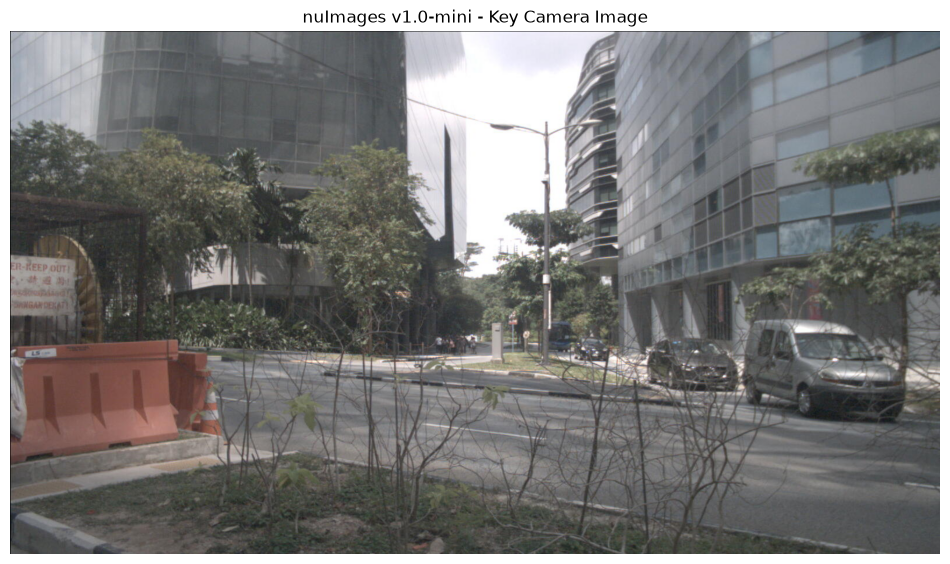

In [16]:
# Display the first key camera image
image = plt.imread(image_path)

plt.figure(figsize=(12,7))
plt.imshow(image)
plt.title("nuImages v1.0-mini - Key Camera Image")
plt.axis("off")
plt.show()

### Observation 

- `sample_data.filename`과 Dataset Root(데이터셋 루트 경로)를 연결하여
  실제 **Key Camera Image(주요 카메라 이미지)**를 정상적으로 불러왔다. 
- Image Metadata(이미지 메타데이터)와 실제 Image File(이미지 파일)의 
  연결이 정상적으로 작동함을 확안하였다. 
- 실제 도로 환경에는 Vehicle(차량), Traffic Cone(교통 콘),
  Barrier(방호벽) 등 다양한 Object(객체)가 포함될 수 있으며,
  일부 객체는 크기가 작거나 다른 객체 및 환경 요소에 의해 가려질 수 있다. 
- 따라서 pilot Annotation(파일럿 라벨링)에서는 Object Class(객체 클래스)뿐 아니라 
  Object Size(객체 크기), Occlusion(가림) 등의 Edge Case (경계사레)를 고려한 Annotation Guideline(라벨링 가이드라인)이 필요하다.

## DU-08. Object Annotation Structure 

nuImages v1.0-mini에 포함된 **Object Annotation(객체 라벨링)**의 
구조와 주요 Field(필드)를 확인한다. 

각 Annotation이 어떤 Image(이미지), Category(카테고리), 
Attribute(속성) 및 **Bounding Box(경계 상자)** 정보를 포함하는지 파악하여 
향후 Manual Annotation(수동 라벨링)과
Ground Truth Comparison(정답 라벨 비교)에 사용할 기준을 이해한다. 

In [17]:
# Convert object annotation metadata to DataFrame
object_ann_df = pd.DataFrame(nuim.object_ann)

print("Object Annotation shape:", object_ann_df.shape)

print("\nObject Annotation columns:")
print(object_ann_df.columns.tolist())

Object Annotation shape: (506, 6)

Object Annotation columns:
['token', 'category_token', 'bbox', 'mask', 'attribute_tokens', 'sample_data_token']


In [18]:
object_ann_df.head()

,token,category_token,bbox,mask,attribute_tokens,sample_data_token
0,00053e5bedec4ee68f0f24193913ed3a,6021b5187b924d64be64a702e5570edf,"[725, 293, 909, 522]","{'size': [900, 1600], 'counts': 'bWxcYzA3a2swO...",[abc0f113547848a9baaa62096fca37f5],daa5b1091bfa45da92c67e78e1dd89aa
1,00332fb1d93f42348785ed2e9ad51ade,653f7efbb9514ce7b81d44070d6208c1,"[318, 459, 381, 498]","{'size': [900, 1600], 'counts': 'U1NnODJvazAzT...",[],8980a5ef00b04d6a9c4544b210467730
2,00e29457d0eb402bbcb96efb4c5256fc,dfd26f200ade4d24b540184e16050022,"[1034, 454, 1146, 571]","{'size': [900, 1600], 'counts': 'ZlRqbTA6UGswS...",[271f6773e4d2496cbb9942c204c8a4c1],a5b934fd32bd49a2a52da91d0e95ad4d
3,013ca27c90d3465a9b5db763cb962ec9,fd69059b62a3469fbaef25340c0eab7f,"[366, 454, 497, 511]","{'size': [900, 1600], 'counts': 'XV1XOmAwX2swN...",[9f65c1eaa74e4d5db46e87a34811e994],4afb21eec056459f87f22525eb9b59b2
4,014c6d598b6341659049734b16bc8034,1fa93b757fc74fb197cdd60001ad8abf,"[987, 415, 1037, 501]","{'size': [900, 1600], 'counts': 'X1JhazA9ZWswN...",[8c92f43bdb7c4df399aac34068f08f0f],1e8072c38b1f4dd2a1aa07ea1624c564


## DU-09. Category Analysis 

`object_ann` Table(테이블)의 `category_token`을 
**Category Metadata(카테고리 메타데이터)**와 연결하여
각 Object Annotation(객체 라벨링)이 어떤 Object Class(객체 클래스)에 
해당하는지 확인한다. 

또한 Category별 Annotation 수를 분석하여 
nuImages v1.0-mini에서 자주 등장하는 객체와 상대적으로 적게 등장하는 
객체를 파악하고, 향후 **Pilot Annotation(파일럿 라벨링)**에 사용할 
Class(클래스)를 선정하기 위한 기초 자료로 활용한다. 

In [19]:
# Convert category metadata to DataFrame
category_df = pd.DataFrame(nuim.category)

print("Category shape:", category_df.shape)

print("\nCategory columns:")
print(category_df.columns.tolist())

category_df.head()

Category shape: (25, 3)

Category columns:
['token', 'name', 'description']


,token,name,description
0,63a94dfa99bb47529567cd90d3b58384,animal,"All animals, e.g. cats, rats, dogs, deer, birds."
1,a86329ee68a0411fb426dcad3b21452f,flat.driveable_surface,Surfaces should be regarded with no concern of...
2,1fa93b757fc74fb197cdd60001ad8abf,human.pedestrian.adult,Adult subcategory.
3,b1c6de4c57f14a5383d9f963fbdcb5cb,human.pedestrian.child,Child subcategory.
4,909f1237d34a49d6bdd27c2fe4581d79,human.pedestrian.construction_worker,Construction worker


### Category Mapping

`object_ann` Table(테이블)의 `category_token`과 
`category` Table의 `token`을 연결하여 각 
**Object Annotation(객체 라벨링)**에 실제 
**Category Name(카테고리명)**을 부여한다. 

이를 통해 Token(토큰) 형태로 저장된 Category 정보를 사람이 이해할 수 있는 
Object Class(객체 클래스)로 변한하고, 이후 
**Class Distribution (클래스 분포)** 분석에 활용한다.

In [20]:
# Map category tokens to category names
object_category_df = object_ann_df.merge(
    category_df[["token", "name"]],
    left_on="category_token",
    right_on="token",
    how="left",
    suffixes=("_annotation","_category")
)

print("Object annotations:", len(object_category_df))
print(
    "Matched categories:",
    object_category_df["name"].notna().sum()
)

object_category_df[
    ["bbox", "name", "attribute_tokens", "sample_data_token"]
].head()

Object annotations: 506
Matched categories: 506


,bbox,name,attribute_tokens,sample_data_token
0,"[725, 293, 909, 522]",vehicle.truck,[abc0f113547848a9baaa62096fca37f5],daa5b1091bfa45da92c67e78e1dd89aa
1,"[318, 459, 381, 498]",movable_object.barrier,[],8980a5ef00b04d6a9c4544b210467730
2,"[1034, 454, 1146, 571]",vehicle.motorcycle,[271f6773e4d2496cbb9942c204c8a4c1],a5b934fd32bd49a2a52da91d0e95ad4d
3,"[366, 454, 497, 511]",vehicle.car,[9f65c1eaa74e4d5db46e87a34811e994],4afb21eec056459f87f22525eb9b59b2
4,"[987, 415, 1037, 501]",human.pedestrian.adult,[8c92f43bdb7c4df399aac34068f08f0f],1e8072c38b1f4dd2a1aa07ea1624c564


### Class Distribution 

Category Mapping(카테고리 매핑)이 완료된 Object Annotation을 기준으로 
각 **Object Class(객체 클래스)**의 Annotation 수와 전체에서 차지하는 
비율을 계산한다. 

Class별 데이터 분포를 확인하여 자주 등장하는 객체와 
**Rare Class(희소 클래스)**를 파악하고,
Pilot Annotation(파일럿 라벨링)의 Class 선정 기준으로 활용한다.

In [21]:
# Calculate class distribution
class_distribution = (
    object_category_df["name"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
)

class_distribution["percentage"] = (
    class_distribution["count"]
    / class_distribution["count"].sum()
    * 100
).round(2)

class_distribution

,category,count,percentage
0,human.pedestrian.adult,189,37.35
1,vehicle.car,122,24.11
2,movable_object.barrier,70,13.83
3,movable_object.trafficcone,44,8.70
4,vehicle.truck,28,5.53
5,vehicle.motorcycle,14,2.77
6,vehicle.bicycle,14,2.77
7,human.pedestrian.construction_worker,6,1.19
8,vehicle.bus.rigid,5,0.99
9,vehicle.construction,5,0.99


### Observation

- 총 **506개의 Object Annotation(객체 라벨링)**에서 
  **15개의 Object Category(객체 카테고리)**가 실제로 사용되고 있다. 
- `human.pedestrian.adult`가 **189개 (37.35%)**로 가장 높은 비중을 차지하며, 
  `vehicle.car`가 **122개(24.11%)**로 두 번째로 높은 비중을 보인다. 
- `movable_object.barrier`는 **70개 (13.83%)**,
  `movable_object.trafficcone`은 **44개(8.70%)**로 나타났다.
- 상위 4개 Category가 전체 Object Annotation의 약 **84.0%**를 차지하여
  뚜렷한 **Class Imbalance(클래스 불균형)**가 존재한다.
- `vehicle.bus.rigid`, `vehicle.construction`, `vehicle.trailer`등의 
  **Rare Class(희소 클래스)**는 Annotation 수가 매우 적으므로,
  단순 Random Sampling(무작위 추출)만으로 Pilot Image(파일럿 이미지)를 
  선정할 경우 일부 Class가 제외될 가능성이 있다.
- 따라서 Pilot Annotation에서는 주요 Class의 대표성과 Rare Class의 
  포함 여부를 함께 고려한 **Stratified Sampling(층화 추출)** 방식의
  Image 선정이 필요하다.

## DU-10. Attribute Analysis 

nuImages의 **Attribute(속성)**는 Object (객체)의 상태 또는 행동 정보를 
표현한다.

예를 들어 동일한 Vehicle(차량)이나 Pedestrian(보행자)이라도
이동 여부, 정차 상태 또는 행동에 따라 서로 다른 Attribute를 가질 수 있다. 

Attribute Metadata(속성 메타데이터)의 구조와 종류를 확인하고,
Object Annotation(객체 라벨링)로 실제로 사용된 Attribute의 분포를 분석한다. 

In [22]:
# Convert attribute metadata to DataFrame
attribute_df = pd.DataFrame(nuim.attribute)

print("Attribute shape:", attribute_df.shape)

print("\nAttribute columns:")
print(attribute_df.columns.tolist())

attribute_df

Attribute shape: (12, 3)

Attribute columns:
['token', 'name', 'description']


,token,name,description
0,271f6773e4d2496cbb9942c204c8a4c1,cycle.with_rider,There is a rider on the bicycle or motorcycle.
1,725f0121878f4c86909f256fd9df8569,cycle.without_rider,There is NO rider on the bicycle or motorcycle.
2,963614d0532a4c6e946d303a94f40a3e,pedestrian.moving,The human is moving.
3,8c92f43bdb7c4df399aac34068f08f0f,pedestrian.sitting_lying_down,The human is sitting or lying down.
4,60346f6d0fcd4d9eadd6f64c77dd1e93,pedestrian.standing,The human is standing.
5,abc0f113547848a9baaa62096fca37f5,vehicle.moving,Vehicle is moving.
6,9f65c1eaa74e4d5db46e87a34811e994,vehicle.parked,Vehicle is stationary (usually for longer dura...
7,46dfc76161234ff1a74eff81da7daab0,vehicle.stopped,"Vehicle, with a driver/rider in/on it, is curr..."
8,3ba0a4fefa8a46f39118e35e45c4111a,vehicle_light.emergency.flashing,Vehicle is flashing emergency lights.
9,67125c542a1e4e25aa05dcf1c3a282b9,vehicle_light.emergency.not_flashing,Vehicle is not flashing emergency lights.


### Attribute Distribution

`object_ann` Table(테이블)의 `attribute_tokens`는 하나 이상의 
**Attribute Token(속성 토큰)**을 List(리스트) 형태로 저장한다. 

`explode()`를 사용하여 Attribute Token을 개별 Record(레코드)로 변환한 뒤, 
`attribute` Table와 연결하여 실제 **Attribute Name(속성명)**을 확인하낟. 

이를 통해 Object (객체)의 상태와 행동이 Dataset(데이터셋)에서 어떻게 분포하는지 분석하고, Pilot Annotation(파일럿 라벨링)에서
Attribute를 포함할지 판단한다. 

In [23]:
# Expand attribute token lists
object_attribute_df = object_ann_df[
    ["token", "category_token", "attribute_tokens"]
].explode("attribute_tokens")

# Map attribute tokens to attribute names
object_attribute_df = object_attribute_df.merge(
    attribute_df[["token", "name"]],
    left_on="attribute_tokens",
    right_on="token",
    how="left",
    suffixes=("_annotation", "_attribute")
)

print("Object annotations:", len(object_ann_df))
print(
    "Annotations with attributes:",
    object_attribute_df["name"].notna().sum()
)

object_attribute_df[
    ["token_annotation", "attribute_tokens", "name"]
].head(10)

Object annotations: 506
Annotations with attributes: 388


,token_annotation,attribute_tokens,name
0,00053e5bedec4ee68f0f24193913ed3a,abc0f113547848a9baaa62096fca37f5,vehicle.moving
1,00332fb1d93f42348785ed2e9ad51ade,NaN,NaN
2,00e29457d0eb402bbcb96efb4c5256fc,271f6773e4d2496cbb9942c204c8a4c1,cycle.with_rider
3,013ca27c90d3465a9b5db763cb962ec9,9f65c1eaa74e4d5db46e87a34811e994,vehicle.parked
4,014c6d598b6341659049734b16bc8034,8c92f43bdb7c4df399aac34068f08f0f,pedestrian.sitting_lying_down
5,01c21ffe79704c4fa6eb7864d6e111ee,8c92f43bdb7c4df399aac34068f08f0f,pedestrian.sitting_lying_down
6,01e549598d184a6fbc6e397c24a2c54f,NaN,NaN
7,02918e3ec65046ae8a9916e453b2d53a,NaN,NaN
8,032e455419044a0eb8f219a4545157d4,abc0f113547848a9baaa62096fca37f5,vehicle.moving
9,033c54c826504702999496dd24978614,9f65c1eaa74e4d5db46e87a34811e994,vehicle.parked


In [24]:
# Calculate attribute distribution
attribute_distribution = (
    object_attribute_df["name"]
    .dropna()
    .value_counts()
    .rename_axis("attribute")
    .reset_index(name="count")
)

attribute_distribution["percentage"] = (
    attribute_distribution["count"]
    / attribute_distribution["count"].sum()
    * 100
).round(2)

attribute_distribution

,attribute,count,percentage
0,pedestrian.moving,100,25.77
1,vehicle.parked,81,20.88
2,vehicle.moving,66,17.01
3,pedestrian.standing,54,13.92
4,pedestrian.sitting_lying_down,41,10.57
5,cycle.without_rider,24,6.19
6,vehicle.stopped,15,3.87
7,cycle.with_rider,7,1.80


In [25]:
# Count annotations without attributes
annotations_without_attribute = object_ann_df[
    object_ann_df["attribute_tokens"].apply(len) == 0
]

print(
    "Annotations without attributes:",
    len(annotations_without_attribute)
)

print(
    "Percentage without attributes:",
    round(
        len(annotations_without_attribute)
        / len(object_ann_df) * 100, 
        2
    ),
    "%"
)

Annotations without attributes: 118
Percentage without attributes: 23.32 %


### Observation

- 총 506개의 **Object Annotation (객체 라벨링)** 중 
  **388개 (76.68%)**에 Attribute(속성)가 부여되지 있으면,
  **188개 (23.32%)**에는 Attribute가 존재하지 않는다.
- Attribute가 부여된 Annotation 중 `pedestrian.moving`이 
  **100개 (25.77%)**로 가장 높은 비중을 차지한다. 
- Vehicle (차량) 관련 Attribute에서는 `vehicle.parked`가 
  **81개(20.88%)**, `vehicle.moving`이 **66개(17.01%)**,
  `vehicle.stopped`가 **15개(3.87%)**로 확인되었다. 
- Pedestrian(보행자)은 `moving`, `standing`, `sitting_lying_down`으로, 
  Cycle(이륜차)은 `with_rider`, `without_rider`로 상태가 구분된다.
- Attribute가 없는 Annotation도 약 **23.32%** 존재하므로,
  Attribute 미부여를 Annotation Error(라벨링 오류)로 간주해서는 안 되며
  Object Category(객체 카테고리)에 따라 Attribute 적용 여부를 구분할 필요가 있다.
- Pilot Annotation(파일럿 라벨링)에서는 Bounding Box(경계 상자)와 
  Category뿐 아니라 주요 Vehicle, Pedestrian 및 Cycle 객체의
  Attribute도 함께 기록하는 방안을 고려한다. 

## DU-11. Bounding Box Analysis 

Object Annotation(객체 라벨링)의 **Bounding Box(경계 상자)** 크기를 분석하여
Dataset(데이터셋)에 포함된 객체의 시각적 규모를 파악한다. 

`bbox`의 `[x_min, y_min, x_max, y_max]` 좌표를 이용하여
각 객체의 **Width(너비), Height(높이), Area(면적)**를 계산한다.

특히 Small Object(소형객체)는 Manual Annotation(수동 라벨링) 과정에서
경계 판단이 어렵고 Bounding Box 위치 오차가 상대적으로 크게 발생할 수 있으므로, 
잠재적 Edge Case(경계사례)를 파악한다.

In [26]:
# Extract bounding box coordinates 
bbox_df = object_category_df.copy()

bbox_df[
    ["x_min", "y_min", "x_max", "y_max"]
] = pd.DataFrame(
    bbox_df["bbox"].tolist(),
    index=bbox_df.index
)

# Calculate bounding box dimensions 
bbox_df["bbox_width"] = bbox_df["x_max"] - bbox_df["x_min"]
bbox_df["bbox_height"] = bbox_df["y_max"] - bbox_df["y_min"]
bbox_df["bbox_area"] = bbox_df["bbox_width"] * bbox_df["bbox_height"]

bbox_df[
    ["name", "bbox", "bbox_width", "bbox_height", "bbox_area"]
].head()

,name,bbox,bbox_width,bbox_height,bbox_area
0,vehicle.truck,"[725, 293, 909, 522]",184,229,42136
1,movable_object.barrier,"[318, 459, 381, 498]",63,39,2457
2,vehicle.motorcycle,"[1034, 454, 1146, 571]",112,117,13104
3,vehicle.car,"[366, 454, 497, 511]",131,57,7467
4,human.pedestrian.adult,"[987, 415, 1037, 501]",50,86,4300


In [27]:
# Summary statistics for bounding box size 
bbox_summary = bbox_df[
    ["bbox_width", "bbox_height", "bbox_area"]
].describe().round(2)

bbox_summary

,bbox_width,bbox_height,bbox_area
count,506.00,506.00,506.00
mean,81.14,83.51,13549.81
std,112.28,82.17,54979.46
min,7.00,11.00,119.00
25%,24.00,34.00,936.00
50%,43.00,61.00,2753.00
75%,94.75,100.00,8268.75
max,1028.00,900.00,925200.00


### Observation

- 506개의 **Object Annotation(객체 라벨링)**에서 Bounding Box(경계 상자)의
  크기가 매우 다양하게 나타났다.
- Bounding Box Width(경계 상자 너비)의 Median(중앙값)은 **43 px**,
  Height(높이)의 Median은 **61 px**이며, 
  Area(면적)의 Median은 **2,753 px²**이다.
- 반면 평균 Area는 **13,549.81 px²**, Maximum Area(최대면적)는
  **925,200 px²**로 나타나 일부 매우 큰 객체가 포함되어 있다. 
- 최초 Bounding Box는 **7 × 17 px**, Area는 **119 px²**로,
  육안으로 식별하기 어려운 Small Object(소형 객체)도 존재한다.
- 이러한 Bounding Box 크기 차이는 Manual Annotation(수동 라벨링)의 
  난이도와 위치 정확도에 영향을 줄 수 잇으므로,
  Small Object를 Quality Assurance(품질 검증)의 주요
  Edge Case(경계사례)로 고려할 필요가 있다. 
  

## DU-12. Relative Bounding Box Size Analysis 

Bounding Box(경계 상자)의 절대 pixel Area(픽셀 면적)뿐 아니라 
전체 Image Area(이미지 면적)에서 객체가 차지하는 비율을 계산한다.

이를 위해 Object Annotation(객체 라벨링)의 `sample_data_token`과 
Sample Data(샘플 데이터)의 Image Resolution(이미지 해상도)을 연결하고,
각 Bounding Box의 **Relative Area(상대 면적)**를 산출한다.

Relative Area를 활용하면 Image Resolution의 영향을 줄이고
Small Object(소형 객체)를 보다 일관된 기준으로 비교할 수 있다. 

In [28]:
# Add image resolution to bounding box data
bbox_relative_df = bbox_df.merge(
    sample_data_df[["token", "width", "height"]],
    left_on="sample_data_token",
    right_on="token",
    how="left",
    suffixes=("_annotation", "_image")
)

print(
    "Matched image resolutions:",
    bbox_relative_df["width"].notna().sum()
)

print(
    "Total object annotations:",
    len(bbox_relative_df)
)

Matched image resolutions: 506
Total object annotations: 506


In [29]:
# Calculate relative bounding box area
bbox_relative_df["image_area"] = (
    bbox_relative_df["width"] * bbox_relative_df["height"]
)

bbox_relative_df["relative_area"] = (
    bbox_relative_df["bbox_area"]
    / bbox_relative_df["image_area"]
)

bbox_relative_df["relative_area_pct"] = (
    bbox_relative_df["relative_area"] * 100
)

bbox_relative_df[
    [
        "name",
        "bbox_area",
        "image_area",
        "relative_area_pct"
    ]
].head()

,name,bbox_area,image_area,relative_area_pct
0,vehicle.truck,42136,1440000,2.926111
1,movable_object.barrier,2457,1440000,0.170625
2,vehicle.motorcycle,13104,1440000,0.910000
3,vehicle.car,7467,1440000,0.518542
4,human.pedestrian.adult,4300,1440000,0.298611


In [30]:
# Summary statistics for relative bounding box area
relative_area_summary = (
    bbox_relative_df["relative_area_pct"]
    .describe()
    .round(4)
)

relative_area_summary

count    506.0000
mean       0.9410
std        3.8180
min        0.0083
25%        0.0650
50%        0.1912
75%        0.5742
max       64.2500
Name: relative_area_pct, dtype: float64